In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!mkdir -p ~/.kaggle

In [4]:
!ls -a /root

.   .bashrc  .config   .julia	 .kaggle  .launchpadlib  .npm	   .tmux.conf
..  .cache   .ipython  .jupyter  .keras   .local	 .profile  .wget-hsts


In [5]:
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
!pip install -q kaggle

In [7]:
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces -p /content/data
!unzip -q /content/data/140k-real-and-fake-faces.zip -d /content/data

Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
100% 3.75G/3.75G [00:34<00:00, 116MB/s]



In [9]:
!zip -r -q /content/drive/MyDrive/140k_faces_extracted.zip /content/data

In [3]:
# copy dataset from drive
!rm -rf /content/data
!mkdir -p /content/data
!cp /content/drive/MyDrive/140k_faces_extracted.zip /content/data/140k_faces_extracted.zip
!unzip -q /content/data/140k_faces_extracted.zip -d /content/data

In [4]:
!mv /content/data/content/data/real_vs_fake /content/data/
!rm -rf /content/data/content

In [5]:
import os

def count_files(directory):
    file_count = 0
    for root, dirs, files in os.walk(directory):
        file_count += len(files)
    return file_count

In [6]:
print(count_files('/content/data/real_vs_fake/real-vs-fake/train'))
print(count_files('/content/data/real_vs_fake/real-vs-fake/test'))
print(count_files('/content/data/real_vs_fake/real-vs-fake/valid'))

100000
20000
20000


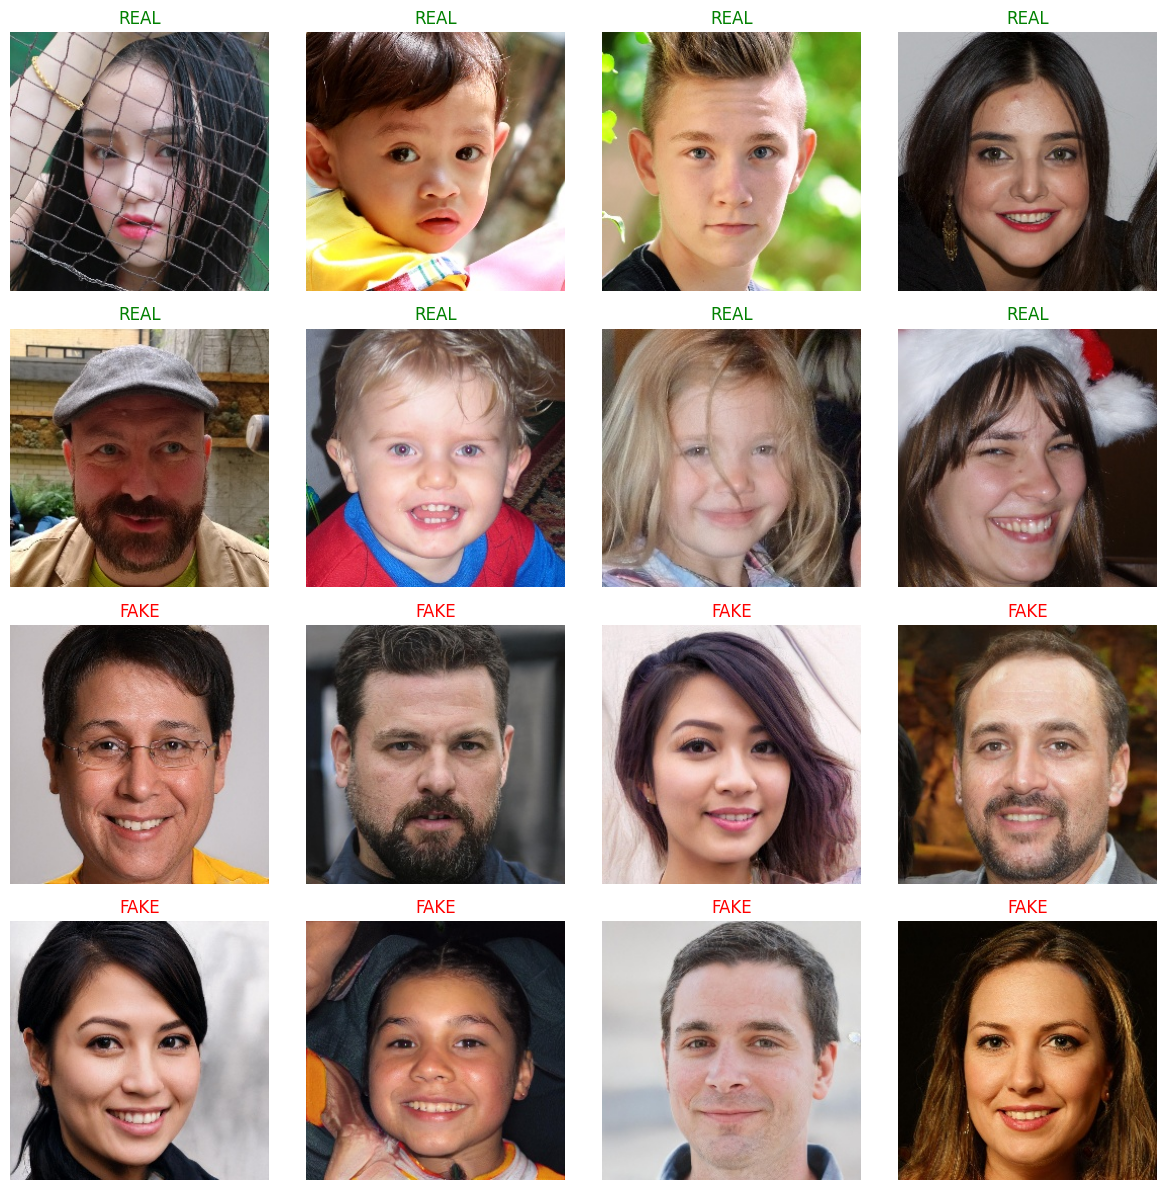

In [7]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import glob

real_dir = '/content/data/real_vs_fake/real-vs-fake/train/real'
fake_dir = '/content/data/real_vs_fake/real-vs-fake/train/fake'

real_imgs = random.sample(glob.glob(f'{real_dir}/*'), 8)
fake_imgs = random.sample(glob.glob(f'{fake_dir}/*'), 8)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, img_path in enumerate(real_imgs):
    ax = axes[i // 4, i % 4]
    ax.imshow(Image.open(img_path))
    ax.set_title('REAL', color='green')
    ax.axis('off')

for i, img_path in enumerate(fake_imgs):
    ax = axes[2 + i // 4, i % 4]
    ax.imshow(Image.open(img_path))
    ax.set_title('FAKE', color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [7]:
bad_files = []
all_files = glob.glob('/content/data/real_vs_fake/real-vs-fake/**/*.jpg', recursive=True)
print(f"Checking {len(all_files)} files...")

for fp in all_files:
    try:
        img = Image.open(fp)
        img.verify()
    except Exception:
        bad_files.append(fp)

print(f"Found {len(bad_files)} corrupt files")

Checking 140000 files...
Found 0 corrupt files


In [8]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import io
import cv2
from torch.optim import lr_scheduler

In [9]:
if torch.cuda.is_available():
    print("CUDA (GPU) is available!")

CUDA (GPU) is available!


In [10]:
# custom augmentation
class RandomJPEGComp:
  def __init__(self, quality_range=(30, 100), p=0.5):
    self.quality_range = quality_range
    self.prob = p

  def __call__(self, img):
    if np.random.random() > self.prob:
      return img
    quality = np.random.randint(*self.quality_range)

    # compression using PIL or OpenCV with 0.5 prob for each

    if np.random.random() < 0.5:
      buffer = io.BytesIO() # temporary file like object in memory
      img.save(buffer, format='JPEG', quality=quality)
      buffer.seek(0) # set buffer current position to beginning for read
      return Image.open(buffer).convert('RGB')

    else:
      img_np = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
      _, enc = cv2.imencode('.jpg', img_np, [int(cv2.IMWRITE_JPEG_QUALITY), quality])
      dec = cv2.imdecode(enc, 1)
      dec = cv2.cvtColor(dec, cv2.COLOR_BGR2RGB)
      return Image.fromarray(dec)


In [11]:
class RandomGaussianBlur:
    def __init__(self, p=0.5, sigma_range=(0, 3)):
        self.p = p
        self.sigma_range = sigma_range

    def __call__(self, img):
        if random.random() > self.p:
            return img
        sigma = random.uniform(*self.sigma_range)
        if sigma == 0:
            return img
        img_np = np.array(img)
        ksize = int(2 * round(3 * sigma) + 1)
        blurred = cv2.GaussianBlur(img_np, (ksize, ksize), sigma)
        return Image.fromarray(blurred)

In [12]:
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    RandomJPEGComp(quality_range=(30, 100), p=0.5),
    # RandomGaussianBlur(p=0.5, sigma_range=(0, 3)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [13]:
DATA_ROOT = '/content/data/real_vs_fake/real-vs-fake'

eval_transform = transforms.Compose([
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(f'{DATA_ROOT}/train', transform=train_transform)
val_dataset = datasets.ImageFolder(f'{DATA_ROOT}/valid', transform=eval_transform)
test_dataset = datasets.ImageFolder(f'{DATA_ROOT}/test', transform=eval_transform)

print(train_dataset.class_to_idx)


{'fake': 0, 'real': 1}


In [14]:
# to create a subset of a dataset with each class having equal number of samples
def stratified_subset(dataset, n_per_class, seed=42):
    targets = np.array(dataset.targets)
    indices = []
    for c in np.unique(targets):
        class_idx = np.where(targets == c)[0]
        chosen = np.random.RandomState(seed).choice(class_idx, size=n_per_class, replace=False)
        indices.extend(chosen)
    return Subset(dataset, indices)

sweep_train_dataset = stratified_subset(train_dataset, n_per_class=9000)  # 18k total
print(f"Full train set: {len(train_dataset)} | Sweep subset: {len(sweep_train_dataset)}")

Full train set: 100000 | Sweep subset: 18000


In [31]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

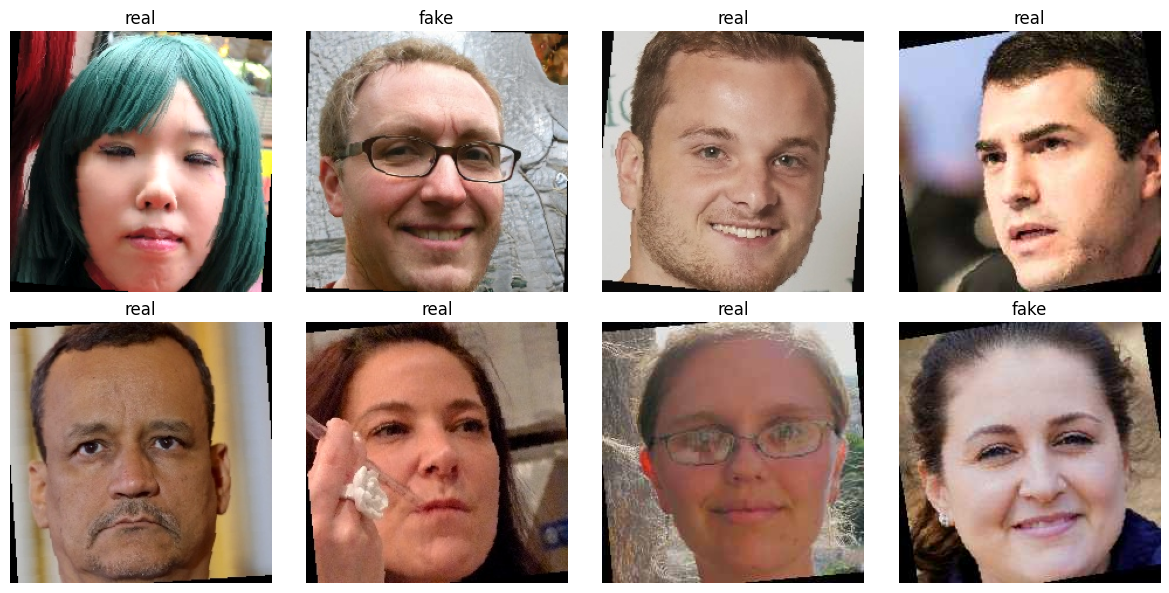

In [32]:
def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std = torch.tensor(IMAGENET_STD).view(3,1,1)
    return tensor * std + mean

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(img)
    ax.set_title(list(train_dataset.class_to_idx.keys())[labels[i]])
    ax.axis('off')
plt.tight_layout()
plt.show()

In [33]:
import torch.nn as nn
from torchvision import models

In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [19]:
# load efficient net b0 model and replace final layer for binary classification
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_features, 2)

model = model.to(device)
print(model.classifier)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 152MB/s]


Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=2, bias=True)
)


In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

In [21]:
model.train()
images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)

outputs = model(images)
print("Output shape:", outputs.shape)

loss = criterion(outputs, labels)
print("Initial loss:", loss.item()) # initial loss approx = ln(2) = 0.69

loss.backward()
optimizer.step()
optimizer.zero_grad()

Output shape: torch.Size([32, 2])
Initial loss: 0.7071388959884644


In [22]:
from tqdm.notebook import tqdm
import time

In [23]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in tqdm(loader, desc="train", leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

In [24]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Val", leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

In [25]:
# test run 1
NUM_EPOCHS = 5
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    elapsed = time.time() - start

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"Val loss {val_loss:.4f} acc {val_acc:.4f} | "
          f"{elapsed:.1f}s")

train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1/5 | Train loss 0.3387 acc 0.8441 | Val loss 0.0921 acc 0.9675 | 175.5s


train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/625 [00:00<?, ?it/s]

...

Val:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 4/5 | Train loss 0.0955 acc 0.9626 | Val loss 0.0381 acc 0.9860 | 154.8s


train:   0%|          | 0/563 [00:00<?, ?it/s]

Val:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 5/5 | Train loss 0.0778 acc 0.9702 | Val loss 0.0641 acc 0.9756 | 156.1s


In [26]:
torch.save(model.state_dict(), '/content/drive/MyDrive/test_run1.pth')

In [1]:
# test run 2 with lr=3e-4,
# NUM_EPOCHS = 3
# history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

# scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

# for epoch in range(NUM_EPOCHS):
#     start = time.time()
#     train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
#     val_loss, val_acc = evaluate(model, val_loader, criterion, device)
#     scheduler.step()
#     elapsed = time.time() - start

#     history['train_loss'].append(train_loss)
#     history['train_acc'].append(train_acc)
#     history['val_loss'].append(val_loss)
#     history['val_acc'].append(val_acc)

#     print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
#           f"Train loss {train_loss:.4f} acc {train_acc:.4f} | "
#           f"Val loss {val_loss:.4f} acc {val_acc:.4f} | "
#           f"{elapsed:.1f}s")

In [35]:
def fresh_model(device):
    m = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    num_features = m.classifier[1].in_features
    m.classifier[1] = nn.Linear(num_features, 2)
    return m.to(device)

model = fresh_model(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

NUM_EPOCHS = 4
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_loss = float('inf')

for epoch in range(NUM_EPOCHS):
    start = time.time()
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    elapsed = time.time() - start

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"Train loss {train_loss:.4f} acc {train_acc:.4f} | "
          f"Val loss {val_loss:.4f} acc {val_acc:.4f} | {elapsed:.1f}s")

    torch.save(model.state_dict(), '/content/drive/MyDrive/checkpoint_run1_latest.pth')
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), '/content/drive/MyDrive/checkpoint_run1_best.pth')
        print(f"New best, saved")

train:   0%|          | 0/3125 [00:00<?, ?it/s]

Val:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1/4 | Train loss 0.1677 acc 0.9294 | Val loss 0.0200 acc 0.9939 | 687.7s
New best, saved


train:   0%|          | 0/3125 [00:00<?, ?it/s]

Val:   0%|          | 0/625 [00:00<?, ?it/s]

...

Val:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 3/4 | Train loss 0.0484 acc 0.9820 | Val loss 0.0154 acc 0.9947 | 633.8s


train:   0%|          | 0/3125 [00:00<?, ?it/s]

Val:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 4/4 | Train loss 0.0377 acc 0.9860 | Val loss 0.0051 acc 0.9981 | 629.1s
New best, saved


In [36]:
model.load_state_dict(torch.load('/content/drive/MyDrive/checkpoint_run1_best.pth'))
model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [60]:
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
confusion_matrix, roc_auc_score, roc_curve, classification_report, auc as sk_auc)
import seaborn as sns

In [38]:
all_labels, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Test"):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)[:, 1]
        preds = outputs.argmax(dim=1)

        all_labels.extend(labels.numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

print("Test Accuracy:", accuracy_score(all_labels, all_preds))
print("\nClassification Report:\n", classification_report(all_labels, all_preds,
      target_names=list(test_dataset.class_to_idx.keys())))
print("ROC-AUC:", roc_auc_score(all_labels, all_probs))

Test:   0%|          | 0/625 [00:00<?, ?it/s]

Test Accuracy: 0.99825

Classification Report:
               precision    recall  f1-score   support

        fake       1.00      1.00      1.00     10000
        real       1.00      1.00      1.00     10000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000

ROC-AUC: 0.9999873100000001


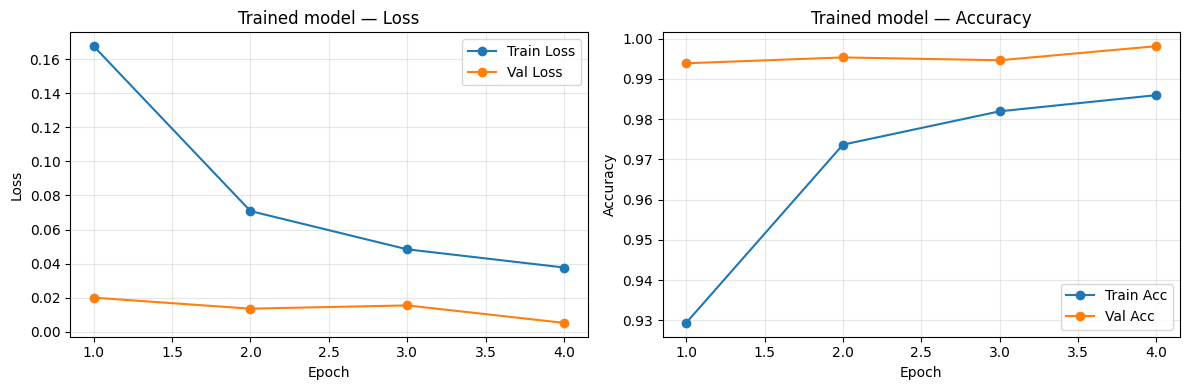

In [39]:
def plot_history(history, title="Training Curves"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    epochs = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs, history['train_loss'], 'o-', label='Train Loss')
    axes[0].plot(epochs, history['val_loss'], 'o-', label='Val Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].set_title(f'{title} — Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs, history['train_acc'], 'o-', label='Train Acc')
    axes[1].plot(epochs, history['val_acc'], 'o-', label='Val Acc')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} — Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history, title="Trained model")

In [40]:
!pip install gradio -q

In [41]:
import gradio as gr

In [42]:
inference_model = fresh_model(device)
inference_model.load_state_dict(
    torch.load('/content/drive/MyDrive/checkpoint_run1_best.pth', map_location=device)
)
inference_model.eval()


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [43]:
inference_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [47]:
def get_logits_labels(model, loader, device):
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            all_logits.append(outputs.cpu())
            all_labels.append(labels)
    return torch.cat(all_logits), torch.cat(all_labels)

val_logits, val_labels = get_logits_labels(inference_model, val_loader, device)

In [48]:
import torch.optim as optim

temperature = nn.Parameter(torch.ones(1, device=device) * 1.5)
nll_criterion = nn.CrossEntropyLoss()

val_logits_d = val_logits.to(device)
val_labels_d = val_labels.to(device)

optimizer = optim.LBFGS([temperature], lr=0.01, max_iter=50)

def eval_loss():
    optimizer.zero_grad()
    loss = nll_criterion(val_logits_d / temperature, val_labels_d)
    loss.backward()
    return loss

optimizer.step(eval_loss)
print(f"Optimal temperature: {temperature.item():.4f}")

Optimal temperature: 1.4960


In [49]:
def compute_ece(logits, labels, temperature=1.0, n_bins=10):
    probs = torch.softmax(logits / temperature, dim=1)
    confidences, predictions = torch.max(probs, dim=1)
    accuracies = predictions.eq(labels)

    ece = 0.0
    bin_boundaries = torch.linspace(0, 1, n_bins + 1)
    for i in range(n_bins):
        in_bin = (confidences > bin_boundaries[i]) & (confidences <= bin_boundaries[i+1])
        prop_in_bin = in_bin.float().mean().item()
        if prop_in_bin > 0:
            acc_in_bin = accuracies[in_bin].float().mean().item()
            conf_in_bin = confidences[in_bin].mean().item()
            ece += abs(conf_in_bin - acc_in_bin) * prop_in_bin
    return ece

print(f"ECE before calibration: {compute_ece(val_logits, val_labels, temperature=1.0):.4f}")
print(f"ECE after calibration:  {compute_ece(val_logits, val_labels, temperature=temperature.item()):.4f}")

ECE before calibration: 0.0014
ECE after calibration:  0.0045


In [44]:
class_names = list(test_dataset.class_to_idx.keys())
print(class_names)

['fake', 'real']


In [50]:
LEARNED_TEMPERATURE = temperature.item()

def predict(image):
    if image is None:
        return None
    image = image.convert('RGB')
    tensor = inference_transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = inference_model(tensor)
        calibrated_logits = outputs / LEARNED_TEMPERATURE
        probs = torch.softmax(calibrated_logits, dim=1)[0]
    return {class_names[i]: float(probs[i]) for i in range(len(class_names))}

In [53]:
demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil", label="Upload a face image"),
    outputs=gr.Label(num_top_classes=2, label="Prediction (calibrated confidence)"),
    title="Deepfake Face Detector (Calibrated)",
    description="Upload a face image — model predicts real vs. AI-generated."
)
demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://95132e77a8ff07540a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 421, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/uvicorn/middleware/proxy_headers.py", line 62, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/fastapi/applications.py", line 1159, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/applications.py", line 107, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/errors.py", line 186, in __call__
    raise exc
  File "/usr/local/lib/python3.12/dist-packages/starlette/middleware/error

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://95132e77a8ff07540a.gradio.live


In [52]:
gr.close_all()

Closing server running on port: 7860
Closing server running on port: 7860
